In [2]:

import sys
import numpy as np
import matplotlib.pyplot as plt


Base de regras:
  R1: fila CURTA  E pedestres POUCOS                      -> verde CURTO
  R2: fila CURTA  E pedestres MODERADOS                   -> verde CURTO
  R3: fila CURTA  E pedestres MUITOS                      -> verde CURTO
  R4: fila MEDIA  E pedestres POUCOS                      -> verde MEDIO
  R5: fila MEDIA  E pedestres MODERADOS                   -> verde MEDIO
  R6: fila MEDIA  E pedestres MUITOS                      -> verde CURTO
  R7: fila LONGA  E (pedestres POUCOS OU MODERADOS)       -> verde LONGO
  R8: fila LONGA  E pedestres MUITOS                      -> verde MEDIO

 Fila  Ped.  Saída (s)   Esperado (s)   OK?  Situação
------------------------------------------------------------------------------
    3     2       15.3     10-25        sim  pouco movimento: não precisa de verde longo
   20     8       35.0     28-42        sim  fila média e poucos pedestres: verde médio
   36     4       54.5     45-60        sim  fila enorme e quase sem pedestres: verde lo

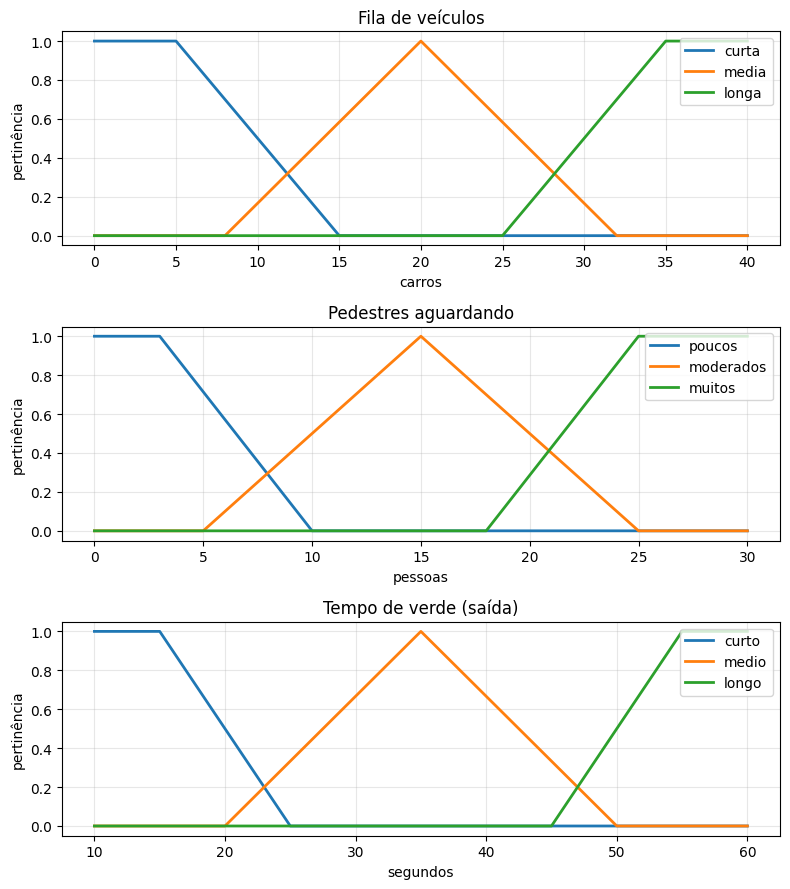

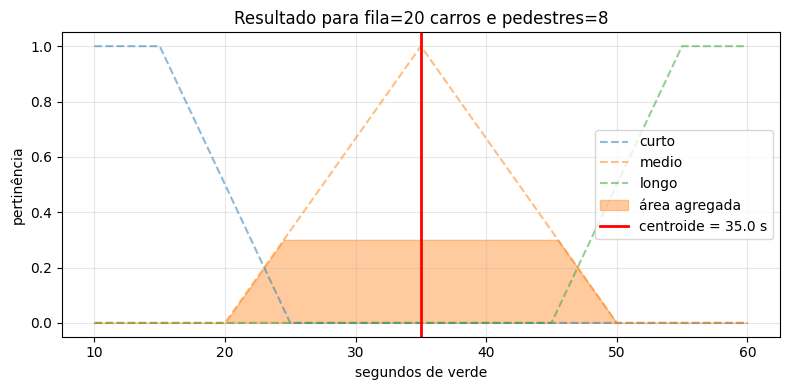

In [4]:
def trapmf(x, a, b, c, d):
    """Trapézio [a, b, c, d]: sobe de a até b, vale 1 de b até c, desce de c até d."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y = np.where((x >= b) & (x <= c), 1.0, y)
    if b > a:
        y = np.where((x > a) & (x < b), (x - a) / (b - a), y)
    if d > c:
        y = np.where((x > c) & (x < d), (d - x) / (d - c), y)
    return y


def trimf(x, a, b, c):
    """Triângulo [a, b, c] (é um trapézio com topo de largura zero)."""
    return trapmf(x, a, b, b, c)


# ---------------------------------------------------------------
# 2) VARIÁVEIS LINGUÍSTICAS (universo + termos)
# ---------------------------------------------------------------
U_FILA = np.arange(0, 40.01, 0.5)    # carros na fila
U_PED = np.arange(0, 30.01, 0.5)     # pedestres aguardando
U_VERDE = np.arange(10, 60.01, 0.5)  # segundos de verde

FILA = {
    "curta": lambda x: trapmf(x, 0, 0, 5, 15),
    "media": lambda x: trimf(x, 8, 20, 32),
    "longa": lambda x: trapmf(x, 25, 35, 40, 40),
}
PED = {
    "poucos": lambda x: trapmf(x, 0, 0, 3, 10),
    "moderados": lambda x: trimf(x, 5, 15, 25),
    "muitos": lambda x: trapmf(x, 18, 25, 30, 30),
}
VERDE = {
    "curto": lambda x: trapmf(x, 10, 10, 15, 25),
    "medio": lambda x: trimf(x, 20, 35, 50),
    "longo": lambda x: trapmf(x, 45, 55, 60, 60),
}


# ---------------------------------------------------------------
# 3) BASE DE REGRAS  (E = mínimo, OU = máximo)
# ---------------------------------------------------------------
# Cada regra recebe os graus de pertinência (f = fila, p = pedestres)
# e devolve (grau de ativação, termo de saída).
REGRAS = [
    ("R1: fila CURTA  E pedestres POUCOS                      -> verde CURTO",
     lambda f, p: min(f["curta"], p["poucos"]), "curto"),
    ("R2: fila CURTA  E pedestres MODERADOS                   -> verde CURTO",
     lambda f, p: min(f["curta"], p["moderados"]), "curto"),
    ("R3: fila CURTA  E pedestres MUITOS                      -> verde CURTO",
     lambda f, p: min(f["curta"], p["muitos"]), "curto"),
    ("R4: fila MEDIA  E pedestres POUCOS                      -> verde MEDIO",
     lambda f, p: min(f["media"], p["poucos"]), "medio"),
    ("R5: fila MEDIA  E pedestres MODERADOS                   -> verde MEDIO",
     lambda f, p: min(f["media"], p["moderados"]), "medio"),
    ("R6: fila MEDIA  E pedestres MUITOS                      -> verde CURTO",
     lambda f, p: min(f["media"], p["muitos"]), "curto"),
    ("R7: fila LONGA  E (pedestres POUCOS OU MODERADOS)       -> verde LONGO",
     lambda f, p: min(f["longa"], max(p["poucos"], p["moderados"])), "longo"),
    ("R8: fila LONGA  E pedestres MUITOS                      -> verde MEDIO",
     lambda f, p: min(f["longa"], p["muitos"]), "medio"),
]


# ---------------------------------------------------------------
# 4) MOTOR DE INFERÊNCIA (Mamdani) + DEFUZZIFICAÇÃO (centroide)
# ---------------------------------------------------------------
def fuzzificar(valor, conjuntos):
    """Grau de pertinência de um valor em cada termo da variável."""
    return {nome: float(mf(np.array([valor]))[0]) for nome, mf in conjuntos.items()}


def inferir(fila, pedestres):
    """Devolve (tempo de verde, graus de entrada, ativações, área agregada)."""
    f = fuzzificar(fila, FILA)
    p = fuzzificar(pedestres, PED)

    # Agregação: união (máximo) dos conjuntos de saída "cortados" pela ativação
    agregada = np.zeros_like(U_VERDE)
    ativacoes = []
    for nome, regra, termo in REGRAS:
        ativ = regra(f, p)
        ativacoes.append((nome, ativ))
        cortado = np.minimum(ativ, VERDE[termo](U_VERDE))
        agregada = np.maximum(agregada, cortado)

    # Defuzzificação: centroide da área agregada
    if agregada.sum() == 0:
        saida = float(U_VERDE.mean())
    else:
        saida = float((U_VERDE * agregada).sum() / agregada.sum())
    return saida, f, p, ativacoes, agregada


# ---------------------------------------------------------------
# 5) TESTES: (fila, pedestres, faixa esperada em segundos, justificativa)
# ---------------------------------------------------------------
TESTES = [
    (3, 2, (10, 25), "pouco movimento: não precisa de verde longo"),
    (20, 8, (28, 42), "fila média e poucos pedestres: verde médio"),
    (36, 4, (45, 60), "fila enorme e quase sem pedestres: verde longo"),
    (36, 28, (28, 42), "fila enorme, mas muitos pedestres: meio-termo"),
    (20, 27, (10, 25), "fila média e muitos pedestres: priorizar pedestres"),
    (38, 14, (45, 60), "fila enorme e pedestres moderados: verde longo"),
]


def rodar_testes():
    print("=" * 78)
    print(f"{'Fila':>5} {'Ped.':>5} {'Saída (s)':>10}  {'Esperado (s)':>13}  {'OK?':^5} Situação")
    print("-" * 78)
    for fila, ped, (lo, hi), motivo in TESTES:
        saida = inferir(fila, ped)[0]
        ok = "sim" if lo <= saida <= hi else "NÃO"
        print(f"{fila:>5} {ped:>5} {saida:>10.1f}  {lo:>5}-{hi:<7}  {ok:^5} {motivo}")
    print("=" * 78)


# ---------------------------------------------------------------
# 6) GRÁFICOS
# ---------------------------------------------------------------
def plotar_pertinencias():
    fig, eixos = plt.subplots(3, 1, figsize=(8, 9))
    for ax, (titulo, universo, conj, rot) in zip(eixos, [
        ("Fila de veículos", U_FILA, FILA, "carros"),
        ("Pedestres aguardando", U_PED, PED, "pessoas"),
        ("Tempo de verde (saída)", U_VERDE, VERDE, "segundos"),
    ]):
        for nome, mf in conj.items():
            ax.plot(universo, mf(universo), label=nome, linewidth=2)
        ax.set_title(titulo)
        ax.set_xlabel(rot)
        ax.set_ylabel("pertinência")
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


def plotar_resultado(fila, pedestres):
    saida, _, _, _, agregada = inferir(fila, pedestres)
    fig, ax = plt.subplots(figsize=(8, 4))
    for nome, mf in VERDE.items():
        ax.plot(U_VERDE, mf(U_VERDE), "--", alpha=0.5, label=nome)
    ax.fill_between(U_VERDE, agregada, alpha=0.4, color="tab:orange", label="área agregada")
    ax.axvline(saida, color="red", linewidth=2, label=f"centroide = {saida:.1f} s")
    ax.set_title(f"Resultado para fila={fila} carros e pedestres={pedestres}")
    ax.set_xlabel("segundos de verde")
    ax.set_ylabel("pertinência")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------
# PRINCIPAL
# ---------------------------------------------------------------
if __name__ == "__main__":
    # Filtra os argumentos que pertencem à inicialização do kernel do Jupyter/Colab
    argumentos = [a for a in sys.argv[1:] if not a.startswith("-") and not a.endswith(".json")]
    mostrar = "--sem-grafico" not in sys.argv

    print("\nBase de regras:")
    for nome, _, _ in REGRAS:
        print("  " + nome)
    print()

    if len(argumentos) == 2:
        try:
            fila, ped = float(argumentos[0]), float(argumentos[1])
            saida = inferir(fila, ped)[0]
            print(f"fila={fila} carros, pedestres={ped} -> verde de {saida:.1f} s")
        except ValueError:
            rodar_testes()
            fila, ped = 20, 8
    else:
        rodar_testes()
        fila, ped = 20, 8

    if mostrar:
        plotar_pertinencias()
        plotar_resultado(fila, ped)
        plt.show()